In [1]:
# Load original dataset

import pandas as pd
from io import StringIO

dataset_path = '../data/merged_emails_with_categories.jsonl'

# Read the file content first
with open(dataset_path, 'r') as f:
    data = f.read()

# Wrap the data in StringIO
original = pd.read_json(StringIO(data), lines=True)

In [2]:
print(len(original))
print(len(original['Subject'].unique()))
subject_counts = original['Subject'].value_counts()

print(subject_counts.describe())
print("Min emails per subject:", subject_counts.min())
print("Max emails per subject:", subject_counts.max())
print("Mean:", subject_counts.mean())
print("Median:", subject_counts.median())

12300
8722
count    8722.000000
mean        1.410227
std         1.294064
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        47.000000
Name: count, dtype: float64
Min emails per subject: 1
Max emails per subject: 47
Mean: 1.410227012153176
Median: 1.0


In [3]:
# Open test set for user study
data_path = '../data/FullList_HumanMails_AnnotationStudy.csv'

import pandas as pd
import chardet

with open(data_path, 'rb') as f:
    result = chardet.detect(f.read())
print(result)  # e.g. {'encoding': 'ISO-8859-1', 'confidence': 0.73}

test_set = pd.read_csv(data_path, encoding=result['encoding'], sep=';')



{'encoding': 'cp850', 'confidence': 0.25842325676778466, 'language': 'en', 'mime_type': 'text/plain'}


In [4]:
print(len(test_set))
print(len(test_set['Subject'].unique()))
subject_counts = test_set['Subject'].value_counts()

print(subject_counts.describe())
print("Min emails per subject:", subject_counts.min())
print("Max emails per subject:", subject_counts.max())
print("Mean:", subject_counts.mean())
print("Median:", subject_counts.median())

1267
1072
count    1072.000000
mean        1.181903
std         0.833209
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        12.000000
Name: count, dtype: float64
Min emails per subject: 1
Max emails per subject: 12
Mean: 1.1819029850746268
Median: 1.0


In [5]:
# Open test set for user study
data_path = '../data/ContentDataset_Pilot.csv'

import pandas as pd
import chardet

with open(data_path, 'rb') as f:
    result = chardet.detect(f.read())
print(result)  # e.g. {'encoding': 'ISO-8859-1', 'confidence': 0.73}

user_set = pd.read_csv(data_path, encoding=result['encoding'], sep=';')

{'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': 'en', 'mime_type': 'text/plain'}


In [6]:
print(len(user_set))
print(len(user_set['Subject'].unique()))


test1_subject_counts = user_set['Subject'].value_counts()

print(subject_counts.describe())
print("Min emails per subject:", subject_counts.min())
print("Max emails per subject:", subject_counts.max())
print("Mean:", subject_counts.mean())
print("Median:", subject_counts.median())

68
68
count    1072.000000
mean        1.181903
std         0.833209
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        12.000000
Name: count, dtype: float64
Min emails per subject: 1
Max emails per subject: 12
Mean: 1.1819029850746268
Median: 1.0


In [7]:
# Check for overlap between sets
print("Overlap train/test:", len(set(test_set['Original email No.']) & set(user_set['Original email No.'])))
print("Overlap original/test:", len(set(original['Original email No.']) & set(test_set['Original email No.'])))
print("Overlap original/train:", len(set(original['Original email No.']) & set(user_set['Original email No.'])))
print(len(user_set), len(test_set))

Overlap train/test: 66
Overlap original/test: 1267
Overlap original/train: 68
68 1267


In [8]:
# Add the language and words columns

from langdetect import detect, DetectorFactory
from tqdm import tqdm
import pandas as pd

# Ensures consistent results every time you run the script
DetectorFactory.seed = 0
save_path = '../data/data.csv'
def analyze_email_body(text):
    if not text or text.strip() == "":
        return {"word_count": 0, "language": "unknown"}

    # 1. Calculate Word Count
    # Splits by whitespace and filters out empty strings
    words = text.split()
    word_count = len(words)

    # 2. Detect Language
    try:
        language = detect(text)
    except Exception:
        language = "could not determine"

    return {
        "word_count": word_count,
        "language": language
    }

languages = []
words = []
for i in tqdm(range(len(original))):
    email_content = original['Body'].iloc[i]
    results = analyze_email_body(email_content)
    languages.append(results['language'])
    words.append(int(results['word_count']))
original['lang'] = languages
original['words'] = words
    

original.to_csv(save_path, index=False)



  0%|          | 0/12300 [00:00<?, ?it/s]

  0%|          | 1/12300 [00:00<53:48,  3.81it/s]

  0%|          | 44/12300 [00:00<01:20, 151.32it/s]

  1%|          | 77/12300 [00:00<00:58, 208.90it/s]

  1%|          | 108/12300 [00:00<00:50, 239.81it/s]

...

 99%|█████████▉| 12198/12300 [00:42<00:00, 245.05it/s]

 99%|█████████▉| 12224/12300 [00:42<00:00, 244.54it/s]

100%|█████████▉| 12251/12300 [00:42<00:00, 249.77it/s]

100%|█████████▉| 12289/12300 [00:42<00:00, 284.72it/s]

100%|██████████| 12300/12300 [00:43<00:00, 285.88it/s]

In [9]:
# Load the saved original dataset
import pandas as pd
data_path = '../data/data.csv'
original = pd.read_csv(data_path)

0               New login on your pCloud account
2                                bitcoin payment
4                      Quote Request - Mol Group
7       New Scanned document from Office Printer
8         Welcome to your Corporate Card Account
                          ...                   
3067    You have been added to our Careers Site!
3068                Your password has been reset
3069                                Zoom Webinar
3073            ⏳ Anonymous, I’m very impatient.
3074            You missed photos from Anonymous
Name: Subject, Length: 2330, dtype: str
Total size 2330


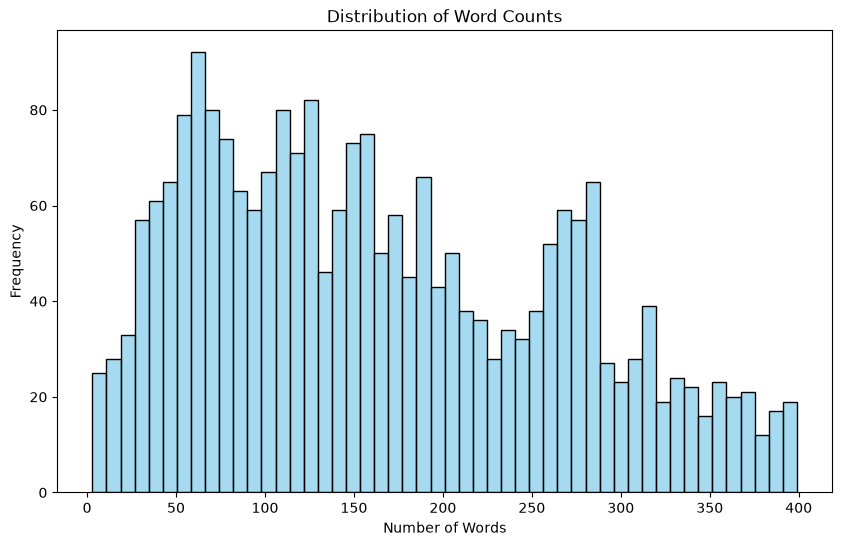

Overlap train/test: 66
Overlap original/test: 1263
Overlap original/train: 68
68 1267
0               New login on your pCloud account
2                                bitcoin payment
4                      Quote Request - Mol Group
7       New Scanned document from Office Printer
8         Welcome to your Corporate Card Account
                          ...                   
3067    You have been added to our Careers Site!
3068                Your password has been reset
3069                                Zoom Webinar
3073            ⏳ Anonymous, I’m very impatient.
3074            You missed photos from Anonymous
Name: Subject, Length: 2330, dtype: str


In [10]:
usable = original[(original['lang'] == 'en') & (original['words'] < 400) & (original['Created by'] == 'Human')]
print(usable['Subject'])
import numpy as np

#usable = usable.dropna(axis=1)
#usable = usable.dropna()
print("Total size", len(usable))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(usable['words'], bins=50, kde=False, color='skyblue')
plt.title('Distribution of Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Check for overlap between sets
print("Overlap train/test:", len(set(test_set['Original email No.']) & set(user_set['Original email No.'])))
print("Overlap original/test:", len(set(usable['Original email No.']) & set(test_set['Original email No.'])))
print("Overlap original/train:", len(set(usable['Original email No.']) & set(user_set['Original email No.'])))
print(len(user_set), len(test_set))
print(usable['Subject'])

In [11]:
# Add sentence embeddings

from sentence_transformers import SentenceTransformer
from tqdm import tqdm
# 1. Initialize the model
# This will automatically download the model and its tokenizer
model = SentenceTransformer('all-MiniLM-L6-v2')

bodies = []
for i in tqdm(range(len(usable))):
    bodies.append(usable['Body'].iloc[i])
# 3. Generate the embeddings
# The 'encode' method handles tokenization and conversion to vectors automatically

embeddings = model.encode(bodies)
dfembs = pd.DataFrame({'embedding': list(embeddings)})

usable = usable.reset_index(drop=True)

usable = pd.concat([usable, dfembs], axis=1)




/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15521.06it/s]

  0%|          | 0/2330 [00:00<?, ?it/s]

100%|██████████| 2330/2330 [00:00<00:00, 42921.77it/s]

In [12]:
# Extract concepts

all_emotions = []
all_motivations = []
from tqdm import tqdm
import ast
print(len(usable))
for i in tqdm(range(len(usable))):
    #print(subset['LLM detected emotion'].iloc[i], i)
    emotions = ast.literal_eval(usable['LLM detected emotion'].iloc[i])
    for e in emotions:
        if e not in all_emotions:
            all_emotions.append(e)
    
    motivations = ast.literal_eval(usable['LLM detected motivation'].iloc[i])
    for m in motivations:
        if m not in all_motivations:
            all_motivations.append(m)

print(all_emotions)
print(len(all_emotions))
print(all_motivations)
print(len(all_motivations))

concept_gts = []
for i in tqdm(range(len(usable))):
    emotions = ast.literal_eval(usable['LLM detected emotion'].iloc[i])
    concepts = []
    for e in all_emotions:
        if e in emotions:
            concepts.append(1)
        else:
            concepts.append(0)
    
    motivations = ast.literal_eval(usable['LLM detected motivation'].iloc[i])
    for m in all_motivations:
        if m in motivations:
            concepts.append(1)
        else:
            concepts.append(0)
    concept_gts.append(concepts)        

print(len(concept_gts))
concept_gts = pd.DataFrame({'concept_gts': concept_gts})


final = pd.concat([usable, concept_gts], axis=1)

import pandas as pd
import numpy as np

print(final.head())
final.to_parquet(
    '../data/preprocess_data.parquet', 
    engine='pyarrow'
)

2330


  0%|          | 0/2330 [00:00<?, ?it/s]

 71%|███████   | 1659/2330 [00:00<00:00, 16582.66it/s]

100%|██████████| 2330/2330 [00:00<00:00, 16546.00it/s]

['Fear', 'Urgency', 'Authority', 'Greed', 'Curiosity', 'Altruism', 'Neutral', 'Humor', 'Promotion/ad', 'Unique', 'Gratitude', 'Blackmail']
12
['Follow the link', 'Reply', 'Open attachment', 'Financial fraud', 'Unknown', 'Promotion/ad', 'Data theft/credential harvesting']
7


  0%|          | 0/2330 [00:00<?, ?it/s]

 67%|██████▋   | 1554/2330 [00:00<00:00, 15531.91it/s]

100%|██████████| 2330/2330 [00:00<00:00, 15886.90it/s]

2330
   No.  Original email No.                                   Subject  \
0    1                   1          New login on your pCloud account   
1    3                   3                           bitcoin payment   
2    5                   5                 Quote Request - Mol Group   
3    8                   8  New Scanned document from Office Printer   
4    9                   9    Welcome to your Corporate Card Account   

                                                Body  \
0  Did you recently log in? Someone just tried to...   
1  Hello Your Wallet is completed and has been fu...   
2  Greetings, Kindly source for the below items a...   
3  Office PrinterYou received a new scanned docum...   
4  CorporateNetDear Anonymous,We provide you and ...   

                                 Sender URL(s) File  \
0  pCloud Team <noreply@isaccess.co.za>    NaN  NaN   
1   PERROT Hugo <Hugo.PERROT@SDIS78.FR>    NaN  NaN   
2  Mol Group <supplies@molgr-team.info>    NaN  NaN   
3    

In [13]:
# Save the concept name list (order matches concept_gts's 19 dims), mirroring
# cub/metadata/cub/concepts.txt -- no hardcoded/external concept-name list needed
from pathlib import Path

concept_names_path = Path('../metadata/emails/concept_names.txt')
concept_names_path.parent.mkdir(parents=True, exist_ok=True)
with open(concept_names_path, 'w') as f:
    f.write('\n'.join(all_emotions + all_motivations))
print(f"Saved {len(all_emotions) + len(all_motivations)} concept names to {concept_names_path}")

Saved 19 concept names to ../metadata/emails/concept_names.txt


In [14]:
print(len(final['concept_gts'].iloc[0]))

19


In [15]:
# Add label column
# and a subset of concepts column (some concepts are merged: Fear and Authority
# are combined into a single "Fear+Authority" concept, since the user study
# only measures 6 concepts, not the full 19)

FEAR_IDX = all_emotions.index('Fear')
AUTHORITY_IDX = all_emotions.index('Authority')
filtered = [all_emotions.index('Urgency'), all_emotions.index('Curiosity'), all_emotions.index('Neutral'),
            len(all_emotions) + all_motivations.index('Reply'),
            len(all_emotions) + all_motivations.index('Open attachment')]

label = []
filtered_concepts = []
for i in range(len(final)):
    if final['Type'].iloc[i] == 'Valid':
        label.append(1)
    elif final['Type'].iloc[i] == 'Phishing':
        label.append(0)
    elif final['Type'].iloc[i] == 'Phishing Simulation':
        label.append(0)
    elif final['Type'].iloc[i] == 'Spam':
        label.append(2)
    else:
        print(final['Type'].iloc[i])
        raise NotImplementedError()

    all_concepts = final['concept_gts'].iloc[i]
    fear_or_authority = 1 if (all_concepts[FEAR_IDX] == 1 or all_concepts[AUTHORITY_IDX] == 1) else 0
    c_sub = [fear_or_authority]
    for f in filtered:
        c_sub.append(all_concepts[f])
    filtered_concepts.append(c_sub)

final['label'] = label
final['concept_gts_f'] = filtered_concepts

# Save the concept_gts_f name list too (order matches its 6 dims), so
# train_concept_extractor2.ipynb doesn't need to re-derive the merge
filtered_concept_names = ['Fear+Authority', 'Urgency', 'Curiosity', 'Neutral', 'Reply', 'Open attachment']
filtered_names_path = Path('../metadata/emails/concept_names_filtered.txt')
filtered_names_path.parent.mkdir(parents=True, exist_ok=True)
with open(filtered_names_path, 'w') as f:
    f.write('\n'.join(filtered_concept_names))
print(f"Saved {len(filtered_concept_names)} filtered concept names to {filtered_names_path}")

Saved 6 filtered concept names to ../metadata/emails/concept_names_filtered.txt


In [16]:
final.head()

,No.,Original email No.,Subject,Body,Sender,URL(s),File,LLM detected emotion,LLM detected motivation,Type,...,LLM category,LLM explanation,anthropic/claude-3.5-sonnet error,anthropic/claude-3.5-sonnet raw_output,lang,words,embedding,concept_gts,label,concept_gts_f
0,1,1,New login on your pCloud account,Did you recently log in? Someone just tried to...,pCloud Team <noreply@isaccess.co.za>,NaN,NaN,"['Fear', 'Urgency', 'Authority']",['Follow the link'],Phishing,...,Phishing,The sender domain 'isaccess.co.za' does not ma...,NaN,NaN,en,99,"[-0.0071150907, -0.01986787, 0.10106177, -0.03...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0,"[1, 1, 0, 0, 0, 0]"
1,3,3,bitcoin payment,Hello Your Wallet is completed and has been fu...,PERROT Hugo <Hugo.PERROT@SDIS78.FR>,NaN,NaN,"['Greed', 'Curiosity']",['Follow the link'],Phishing,...,Phishing,Classic cryptocurrency scam attempting to lure...,NaN,NaN,en,25,"[-0.041165404, -0.014455044, -0.03174453, -0.0...","[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0,"[0, 0, 1, 0, 0, 0]"
2,5,5,Quote Request - Mol Group,"Greetings, Kindly source for the below items a...",Mol Group <supplies@molgr-team.info>,NaN,NaN,"['Urgency', 'Authority']",['Reply'],Phishing,...,Phishing,Multiple red flags: Sender domain 'molgr-team....,NaN,NaN,en,54,"[-0.10272602, 0.014642002, 0.06047538, -0.0185...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0,"[1, 1, 0, 0, 1, 0]"
3,8,8,New Scanned document from Office Printer,Office PrinterYou received a new scanned docum...,NaN,NaN,NaN,"['Curiosity', 'Urgency']",['Follow the link'],Phishing Simulation,...,Phishing,Classic printer phishing attempt using common ...,NaN,NaN,en,43,"[-0.056883752, 0.07338459, -0.08203927, -0.045...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0,"[0, 1, 1, 0, 0, 0]"
4,9,9,Welcome to your Corporate Card Account,"CorporateNetDear Anonymous,We provide you and ...",NaN,NaN,NaN,"['Authority', 'Urgency']",['Follow the link'],Phishing Simulation,...,Phishing,This appears to be a phishing attempt targetin...,NaN,NaN,en,131,"[-0.057312947, -0.017109444, -0.008237381, -0....","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0,"[1, 1, 0, 0, 0, 0]"


In [17]:
# Check for overlap between sets
print("Overlap test_sub/test:", len(set(test_set['Original email No.']) & set(user_set['Original email No.'])))
print("Overlap original/test:", len(set(final['Original email No.']) & set(test_set['Original email No.'])))
print("Overlap original/train:", len(set(final['Original email No.']) & set(user_set['Original email No.'])))
print(len(user_set), len(test_set))

user_set = final[final['Original email No.'].isin(user_set['Original email No.'])]
user_set.head()
print("Overlap test_sub/test:", len(set(test_set['Original email No.']) & set(user_set['Original email No.'])))
print("Overlap original/test:", len(set(final['Original email No.']) & set(test_set['Original email No.'])))
print("Overlap original/train:", len(set(final['Original email No.']) & set(user_set['Original email No.'])))
print(len(user_set), len(test_set))

Overlap test_sub/test: 66
Overlap original/test: 1263
Overlap original/train: 68
68 1267
Overlap test_sub/test: 66
Overlap original/test: 1263
Overlap original/train: 68
68 1267


In [18]:
valid_unique_sub = final[final['label'] == 1]
needs_to_be_separated = valid_unique_sub[valid_unique_sub.duplicated(subset='Subject', keep=False)]
print(needs_to_be_separated['Subject'])


96         Re: [zzzzteana] Nothing like mama used to make
97         Re: [zzzzteana] Nothing like mama used to make
99         Re: [zzzzteana] Nothing like mama used to make
110                 Re: [zzzzteana] Which Muppet Are You?
111                              Re: [ILUG] Sun Solaris..
                              ...                        
2291    Re: [opensuse] openSUSE 11.0 and the Non-ready...
2292    RE: [perl #45513] Test failures on amd64-freeb...
2296    Re: [opensuse] openSUSE 11.0 and the Non-ready...
2297    Re: [opensuse] openSUSE 11.0 and the Non-ready...
2307    Re: postfix in a courier proxy cluster wont de...
Name: Subject, Length: 289, dtype: str


In [19]:
test_set = final[final['Original email No.'].isin(test_set['Original email No.'])]
test_set.head()

print("Overlap with subset:", len(set(test_set['Original email No.']) & set(needs_to_be_separated['Original email No.'])))
print("Overlap with subsubset:", len(set(user_set['Original email No.']) & set(needs_to_be_separated['Original email No.'])))
#print("Overlap original/train:", len(set(final['Original email No.']) & set(needs_to_be_separated['Original email No.'])))
print(len(user_set), len(test_set))

Overlap with subset: 245
Overlap with subsubset: 0
68 1263


In [20]:
# Print the length of each subset

print(f"Original: {len(final)}\n Test set: {len(test_set)}\n User set: {len(user_set)}")


Original: 2330
 Test set: 1263
 User set: 68


In [21]:
pos = final[final['label'] == 1]
neg = final[final['label'] == 0]

print(len(pos), len(neg))

731 958


In [22]:
# Check the number of positive and negative samples in the test set

print(len(test_set[test_set['label'] == 1]),
      len(test_set[test_set['label'] == 0]))

print(len(user_set[user_set['label'] == 1]),
      len(user_set[user_set['label'] == 0]))


567 696
28 40


In [23]:
# add 

TARGET_NUMBER_OF_SAMPLES_PER_CLASS = 500
pos_to_add = TARGET_NUMBER_OF_SAMPLES_PER_CLASS - len(user_set[user_set['label'] == 1])
neg_to_add = TARGET_NUMBER_OF_SAMPLES_PER_CLASS - len(user_set[user_set['label'] == 0])
print(pos_to_add, neg_to_add)

472 460


In [24]:
print("Overlap train/test:", len(set(test_set['Original email No.']) & set(user_set['Original email No.'])))
print("Overlap original/test:", len(set(final['Original email No.']) & set(test_set['Original email No.'])))
print("Overlap original/train:", len(set(final['Original email No.']) & set(user_set['Original email No.'])))
print(len(user_set), len(test_set))

Overlap train/test: 66
Overlap original/test: 1263
Overlap original/train: 68
68 1263


In [25]:
test_not_in_user = test_set[~test_set['Original email No.'].isin(user_set['Original email No.'])]

extra_pos = test_not_in_user[test_not_in_user['label'] == 1].sample(n=pos_to_add, random_state=42)
extra_neg = test_not_in_user[test_not_in_user['label'] == 0].sample(n=neg_to_add, random_state=42)

balanced_user_set = pd.concat([user_set, extra_pos, extra_neg]).reset_index(drop=True)

leftovers = final[~final['Original email No.'].isin(balanced_user_set['Original email No.'])]
print("--------------------")
print(f"Size of the original set {len(final)}")
print(f"Valid {len(final[final['label'] == 1])} Phishing {len(final[final['label'] == 0])}")

print("--------------------")
print(f"Size of the test set {len(balanced_user_set)}")
print(f"Valid {len(balanced_user_set[balanced_user_set['label'] == 1])} Phishing {len(balanced_user_set[balanced_user_set['label'] == 0])}")

print("--------------------")
print(f"Remainder (train set) {len(leftovers)}")
print(f"Valid {len(leftovers[leftovers['label'] == 1])} Phishing {len(leftovers[leftovers['label'] == 0])}")

print("Overlap with subset:", len(set(leftovers['Original email No.']) & set(needs_to_be_separated['Original email No.'])))
print("Overlap with subsubset:", len(set(balanced_user_set['Original email No.']) & set(needs_to_be_separated['Original email No.'])))


--------------------
Size of the original set 2330
Valid 731 Phishing 958
--------------------
Size of the test set 1000
Valid 500 Phishing 500
--------------------
Remainder (train set) 1330
Valid 231 Phishing 458
Overlap with subset: 78
Overlap with subsubset: 211


In [26]:
# Count occurrences of each duplicated subject
subject_counts = final[final['Subject'].isin(needs_to_be_separated['Subject'])]['Subject'].value_counts().reset_index()
subject_counts.columns = ['Subject', 'count']
print(subject_counts)

THRESHOLD = 5

few_dup_subjects = subject_counts[subject_counts['count'] < THRESHOLD]['Subject']
print(len(few_dup_subjects))

many_dup_subjects = subject_counts[subject_counts['count'] >= THRESHOLD]['Subject']
print(len(many_dup_subjects))


                                              Subject  count
0                          Re: [opensuse] OpenSuse 11     12
1   Re: [opensuse] Intel 3945 Wireless Problem ope...     12
2                   Re: [opensuse] openSUSE and faxes     10
3                  Re: [spambayes-dev] spoof detector      9
4                     Re: Mail attachements truncated      8
..                                                ...    ...
78  Re: [spambayes-dev] Should we cull the list of...      2
79  Re: [opensuse] Update runs in loop...Amarak/Fi...      2
80  Re: [spambayes-dev] Help: bsddb._db.DBAccessEr...      2
81  Re: postfix in a courier proxy cluster wont de...      2
82  RE: [perl #45513] Test failures on amd64-freeb...      2

[83 rows x 2 columns]
68
15


In [27]:
# Rows to move to balanced_user_set (few duplicates not already there)
rows_few = leftovers[leftovers['Subject'].isin(few_dup_subjects)]
# Rows to move to leftovers (many duplicates not already there)
rows_many = balanced_user_set[balanced_user_set['Subject'].isin(many_dup_subjects)]

#print(len(rows_few), len(rows_many))
# Update both dataframes
balanced_user_set_tmp = pd.concat([balanced_user_set, rows_few]).reset_index(drop=True)
#print(len(balanced_user_set)-len(balanced_user_set_tmp))
balanced_user_set_tmp = balanced_user_set_tmp[~balanced_user_set_tmp['Subject'].isin(many_dup_subjects)]
#print(len(balanced_user_set)-len(balanced_user_set_tmp))

leftovers_tmp = pd.concat([leftovers, rows_many]).reset_index(drop=True)
#print(len(leftovers)-len(leftovers_tmp))
leftovers_tmp = leftovers_tmp[~leftovers_tmp['Subject'].isin(few_dup_subjects)]
#print(len(leftovers)-len(leftovers_tmp))

#print(len(leftovers) + len(balanced_user_set))
#print(len(leftovers_tmp)+len(balanced_user_set_tmp))
print("--------------------")
print(f"Size of the original set {len(final)}")
print(f"Valid {len(final[final['label'] == 1])} Phishing {len(final[final['label'] == 0])}")

print("--------------------")
print(f"Size of the test set {len(balanced_user_set_tmp)}")
print(f"Valid {len(balanced_user_set_tmp[balanced_user_set_tmp['label'] == 1])} Phishing {len(balanced_user_set_tmp[balanced_user_set_tmp['label'] == 0])}")

print("--------------------")
print(f"Remainder (train set) {len(leftovers_tmp)}")
print(f"Valid {len(leftovers_tmp[leftovers_tmp['label'] == 1])} Phishing {len(leftovers_tmp[leftovers_tmp['label'] == 0])}")

print('')
print(len(balanced_user_set_tmp)+len(leftovers_tmp), '=?',len(final))

--------------------
Size of the original set 2330
Valid 731 Phishing 958
--------------------
Size of the test set 964
Valid 464 Phishing 500
--------------------
Remainder (train set) 1366
Valid 267 Phishing 458

2330 =? 2330


In [28]:
N = 36  # define how many additional rows you want to sample

# Subjects eligible to move: not duplicated, or duplicated but fewer than 3 times
eligible_subjects = subject_counts[subject_counts['count'] < 3]['Subject'].tolist()
eligible_subjects += list(final[~final['Subject'].isin(subject_counts['Subject'])]['Subject'].unique())

# Sample from leftovers with label==1 and eligible subjects
eligible_rows = leftovers_tmp[
    (leftovers_tmp['label'] == 1) & 
    (leftovers_tmp['Subject'].isin(eligible_subjects))
]

sampled = eligible_rows.sample(n=N, random_state=42)
print(sampled)
# Move sampled rows to balanced_user_set
balanced_user_set_tmp2 = pd.concat([balanced_user_set_tmp, sampled]).reset_index(drop=True)
leftovers_tmp2 = leftovers_tmp[~leftovers_tmp['Original email No.'].isin(sampled['Original email No.'])].reset_index(drop=True)

print('')
print(len(balanced_user_set_tmp2)+len(leftovers_tmp2), '=?',len(final))

       No.  Original email No.  \
1203  2598                2598   
1206  2603                2603   
1220  2653                2653   
1252  2774                2774   
1135  2325                2325   
1249  2763                2763   
1196  2580                2580   
1199  2591                2591   
1115  2236                2236   
1112  2223                2223   
1116  2245                2245   
1109  2217                2217   
110    297                 297   
1152  2411                2411   
1164  2440                2440   
1185  2549                2549   
1243  2733                2733   
1296  2950                2950   
1181  2515                2515   
1219  2647                2647   
1191  2561                2561   
1278  2903                2903   
1137  2329                2329   
1182  2517                2517   
1168  2455                2455   
1136  2328                2328   
1130  2299                2299   
1288  2932                2932   
1295  2949    

In [29]:
print("--------------------")
print(f"Size of the original set {len(final)}")
print(f"Valid {len(final[final['label'] == 1])} Phishing {len(final[final['label'] == 0])}")

print("--------------------")
print(f"Size of the test set {len(balanced_user_set_tmp)}")
print(f"Valid {len(balanced_user_set_tmp2[balanced_user_set_tmp2['label'] == 1])} Phishing {len(balanced_user_set_tmp2[balanced_user_set_tmp2['label'] == 0])}")

print("--------------------")
print(f"Remainder (train set) {len(leftovers_tmp)}")
print(f"Valid {len(leftovers_tmp2[leftovers_tmp2['label'] == 1])} Phishing {len(leftovers_tmp2[leftovers_tmp2['label'] == 0])}")

--------------------
Size of the original set 2330


Valid 731 Phishing 958
--------------------
Size of the test set 964
Valid 500 Phishing 500
--------------------
Remainder (train set) 1366
Valid 231 Phishing 458


In [30]:
# Check for overlap between sets
print("Overlap train/test:", len(set(leftovers['Original email No.']) & set(balanced_user_set['Original email No.'])))
print("Overlap original/test:", len(set(final['Original email No.']) & set(balanced_user_set['Original email No.'])))
print("Overlap original/train:", len(set(final['Original email No.']) & set(leftovers['Original email No.'])))

# Check total
print("\nTotal accounted for:", len(leftovers_tmp2) + len(balanced_user_set_tmp2))
print("Original:", len(final))

Overlap train/test: 0
Overlap original/test: 1000
Overlap original/train: 1330

Total accounted for: 2330
Original: 2330


In [31]:
# Create a stratified train-val to train the model

from sklearn.model_selection import train_test_split

# 1. Bin the words column into quantile-based buckets
leftovers_tmp2['words_bin'] = pd.qcut(leftovers_tmp2['words'], q=6, labels=False, duplicates='drop')

# 2. Create a combined stratification key
leftovers_tmp2['strat_key'] = leftovers_tmp2['label'].astype(str) + '_' + leftovers_tmp2['words_bin'].astype(str)

# 3. Split
train, test = train_test_split(
    leftovers_tmp2,
    test_size=0.2,
    random_state=42,
    stratify=leftovers_tmp2['strat_key']
)

# 4. Clean up helper columns
train = train.drop(columns=['strat_key'])
print(f"The concept extractor has {len(train)} train samples")
val  = test.drop(columns=['strat_key'])
print(f"The concept extractor has {len(val)} validation samples")

train_class = train[train['label'].isin([0, 1])]
val_class = val[val['label'].isin([0, 1])]
print(f"The Class predictor has {len(train_class)} train samples")
print(f"The Class predictor has {len(val_class)} validation samples")

The concept extractor has 1064 train samples
The concept extractor has 266 validation samples


The Class predictor has 551 train samples
The Class predictor has 138 validation samples


In [32]:
def compare_distributions(train, test, col):
    print(f"\n--- {col} ---")
    print("Train:\n", train[col].value_counts(normalize=True).sort_index())
    print("Test:\n",  test[col].value_counts(normalize=True).sort_index())

compare_distributions(train, test, 'label')
compare_distributions(train, test, 'words_bin')



--- label ---
Train:
 label
0    0.343985
1    0.173872
2    0.482143
Name: proportion, dtype: float64
Test:
 label
0    0.345865
1    0.172932
2    0.481203
Name: proportion, dtype: float64

--- words_bin ---
Train:
 words_bin
0    0.169173
1    0.165414
2    0.166353
3    0.167293
4    0.166353
5    0.165414
Name: proportion, dtype: float64
Test:
 words_bin
0    0.172932
1    0.165414
2    0.165414
3    0.165414
4    0.165414
5    0.165414
Name: proportion, dtype: float64


In [33]:
train_sub = train['Subject'].unique()
val_sub = val['Subject'].unique()
test_sub = balanced_user_set_tmp2['Subject'].unique()

# Intersections between each pair
train_val = set(train_sub) & set(val_sub)
train_test = set(train_sub) & set(test_sub)
val_test = set(val_sub) & set(test_sub)

print(f"Train ∩ Val:  {len(train_val)} subjects")
print(f"Train ∩ Test: {len(train_test)} subjects")
print(f"Val ∩ Test:  {len(val_test)} subjects")

if train_val:
    print("\nTrain ∩ Val subject counts:")
    for sub in train_val:
        t = (train['Subject'] == sub).sum()
        v = (val['Subject'] == sub).sum()
        print(f"  '{sub}': {t} in train, {v} in val")
    for sub in train_test:
        t = (train['Subject'] == sub).sum()
        v = (val['Subject'] == sub).sum()
        print(f"  '{sub}': {t} in train, {v} in test")

Train ∩ Val:  41 subjects


Train ∩ Test: 30 subjects
Val ∩ Test:  10 subjects

Train ∩ Val subject counts:
  'Set your sights on Saint Laurent’s latest arrivals': 1 in train, 1 in val
  'Re: Luis' shorts Re: iPhone hacking Re: [FoRK] Thinking of taking an iPhone on an international trip?': 3 in train, 3 in val
  'Information': 1 in train, 2 in val
  'Project Funding.': 1 in train, 1 in val
  'Re: sa-learn --ham ground rules': 7 in train, 1 in val
  'Re: [opensuse]  Unstable system - who is the culprit?': 4 in train, 1 in val
  'Want to learn more about your skin? Take the YesStyle Beauty Quiz': 1 in train, 1 in val
  'What Team NET-A-PORTER wears on vacation': 1 in train, 1 in val
  'We're having some trouble with your current billing information ': 1 in train, 1 in val
  'quick question': 1 in train, 1 in val
  'Clean your ears without hurting yourself  👂': 1 in train, 1 in val
  'Account Verification': 2 in train, 1 in val


  'Ready for the long weekend?': 1 in train, 1 in val
  'Click to confirm your subscription': 1 in train, 1 in val
  'Re-Validate E-mail Password': 2 in train, 1 in val
  'Re: server is rejecting mail from single domain': 3 in train, 3 in val
  'Treat yourself to something new': 1 in train, 1 in val
  '6 ways to style out summer in the city': 1 in train, 1 in val
  'Welcome to the YesStyle Elite Club!': 1 in train, 1 in val
  'Security Update': 1 in train, 1 in val
  'Re: [opensuse] Intel 3945 Wireless Problem opensuse 10.3 - RESOLVED!': 9 in train, 3 in val
  'Netflix : We're having some trouble with your current billing
 information': 2 in train, 1 in val
  'The ultimate vacation style cheat sheet': 1 in train, 1 in val


  'Want to know what to wear today?': 1 in train, 1 in val
  'Confirm Your Transaction': 1 in train, 1 in val
  'Flash Sale ⚡ 50% off swimwear for all': 1 in train, 1 in val
  'The Row’s easy elegance': 1 in train, 1 in val
  'Your new favorites have arrived': 1 in train, 1 in val
  'Re: [opensuse]  Power Supply PSU Efficiency (was: Unstable system - who is the culprit?': 4 in train, 1 in val
  'New season = new closet staples': 1 in train, 1 in val
  'Re: [opensuse] openSUSE and faxes': 9 in train, 1 in val
  'New week, new arrivals': 1 in train, 1 in val
  'The Hero: Our Exclusive Mini Bag From Advene': 1 in train, 1 in val
  '[Bug 5820] URIBL_SBL from zen?': 4 in train, 3 in val
  'Want even BIGGER SAVINGS from YesStyle?': 1 in train, 2 in val
  'Enjoy up to 50% off these wardrobe heroes': 1 in train, 1 in val
  'Your Billing Information is missing': 1 in train, 1 in val
  'The looks to love, straight from the shows': 1 in train, 1 in val
  'Up to 50% off our star designers': 1 in t

In [34]:
balanced_user_set_tmp2.to_parquet(
    '../data/user_study_data.parquet', 
    engine='pyarrow'
)

train.to_parquet(
    '../data/train.parquet', 
    engine='pyarrow'
)

val.to_parquet(
    '../data/val.parquet', 
    engine='pyarrow'
)

In [35]:
print(balanced_user_set.keys())
balanced_user_set_tmp2.drop(columns=['embedding']).to_csv('../data/balanced_user_set.csv', index=False)
leftovers_tmp2.drop(columns=['embedding']).to_csv('../data/train.csv', index=False)

Index(['No.', 'Original email No.', 'Subject', 'Body', 'Sender', 'URL(s)',
       'File', 'LLM detected emotion', 'LLM detected motivation', 'Type',
       'Created by', 'Source', 'Year', 'LLM category', 'LLM explanation',
       'anthropic/claude-3.5-sonnet error',
       'anthropic/claude-3.5-sonnet raw_output', 'lang', 'words', 'embedding',
       'concept_gts', 'label', 'concept_gts_f'],
      dtype='str')


In [36]:
# Also persist the embeddings separately, mirroring cub/data/clip_embeddings/*.pt
# (additive -- 'embedding' stays in the parquets too, since train_concept_extractor2
# reads it from there directly)
import torch
from pathlib import Path

embeddings_dir = Path('../data/text_embeddings')
embeddings_dir.mkdir(parents=True, exist_ok=True)

splits = {
    'train': train,
    'val': val,
    'user_study': balanced_user_set_tmp2,
}
for split_name, split_df in splits.items():
    embeddings = torch.tensor(np.stack(split_df['embedding'].values))
    out_path = embeddings_dir / f'{split_name}_embeddings.pt'
    torch.save(embeddings, out_path)
    print(f"Saved {embeddings.shape} to {out_path}")

Saved torch.Size([1064, 384]) to ../data/text_embeddings/train_embeddings.pt
Saved torch.Size([266, 384]) to ../data/text_embeddings/val_embeddings.pt
Saved torch.Size([1000, 384]) to ../data/text_embeddings/user_study_embeddings.pt
